# Week 7 — Recommendation System
## Exploratory Data Analysis (EDA)
**Author:** Martin James Ng'ang'a | MLOps Engineer | Nairobi, Kenya 🇰🇪  
**GitHub:** github.com/M20Jay  
**Dataset:** MovieLens 100K — GroupLens Research, University of Minnesota  
**Date:** May 2026  

---

### Dataset Overview
- **100,000 ratings** (1-5) from **943 users** on **1,682 movies**
- Each user has rated at least 20 movies
- Collected: September 1997 — April 1998
- Files: u.data · u.item · u.user · u1.base · u1.test

---

### EDA Objectives
1. Understand rating distribution patterns
2. Identify active users and popular movies
3. Analyse genre preferences
4. Measure matrix sparsity
5. Inform model selection and preprocessing decisions

---
## Section 1 — Project Setup and Imports

Load all required libraries and configure the notebook environment.

In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

RAW_PATH = "../data/raw/"

print("✅ Libraries loaded successfully")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


✅ Libraries loaded successfully
pandas: 2.2.2
numpy: 1.26.4


**Section 1 Findings:**
- ✅ All libraries loaded successfully
- pandas 2.2.2 · numpy 1.26.4
- Plot style set to seaborn-v0_8 — clean professional visuals
- Colour palette set to husl — distinguishes multiple categories clearly
- RAW_PATH set to ../data/raw/ — single definition, used everywhere
- Figure size set to (12, 6) — wide enough for distribution plots
- Font size set to 12 — readable in notebook and exports

---
## Section 2 — Load and Inspect Raw Data

Load all four MovieLens files and inspect shape, dtypes, and sample rows.
Each file has a different separator and encoding — understanding why matters before loading.

- **u.data** → tab-separated · 100,000 ratings · user_id | item_id | rating | timestamp
- **u.item** → pipe-separated · latin-1 encoding · 1,682 movies · 24 columns including 19 genre flags
- **u.user** → pipe-separated · 943 users · age | gender | occupation | zip_code

In [3]:
# Load ratings — tab-separated, no header
ratings = pd.read_csv(RAW_PATH + "u.data", sep="\t",
                      names=["user_id", "item_id", "rating", "timestamp"])

# Load movies — pipe-separated, latin-1 encoding (1997 data)
movies = pd.read_csv(RAW_PATH + "u.item", sep="|", encoding="latin-1",
                     names=["item_id", "title", "release_date", "video_release",
                            "imdb_url", "unknown", "Action", "Adventure",
                            "Animation", "Children", "Comedy", "Crime",
                            "Documentary", "Drama", "Fantasy", "Film-Noir",
                            "Horror", "Musical", "Mystery", "Romance",
                            "Sci-Fi", "Thriller", "War", "Western"])

# Load users — pipe-separated
users = pd.read_csv(RAW_PATH + "u.user", sep="|",
                    names=["user_id", "age", "gender", "occupation", "zip_code"])

print(f"✅ Ratings shape : {ratings.shape}")
print(f"✅ Movies shape  : {movies.shape}")
print(f"✅ Users shape   : {users.shape}")
print("\n--- Ratings sample ---")
display(ratings.head())
print("\n--- Movies sample ---")
display(movies[["item_id", "title", "release_date"]].head())
print("\n--- Users sample ---")
display(users.head())

✅ Ratings shape : (100000, 4)
✅ Movies shape  : (1682, 24)
✅ Users shape   : (943, 5)

--- Ratings sample ---


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



--- Movies sample ---


,item_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995



--- Users sample ---


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


**Section 2 Findings:**
- ✅ All three files loaded successfully
- Ratings: 100,000 events across 943 users and 1,682 movies
- Timestamps are Unix format — will convert in Section 3
- Movie titles include release year in brackets — useful for feature engineering
- Genre columns are binary flags — one movie can belong to multiple genres
- Users are predominantly young males based on first 5 rows — will analyse fully in Section 7

---
## Section 3 — Ratings Distribution Analysis

Understand how ratings are distributed across 1–5.
Identify bias, skew, and what this means for modelling.

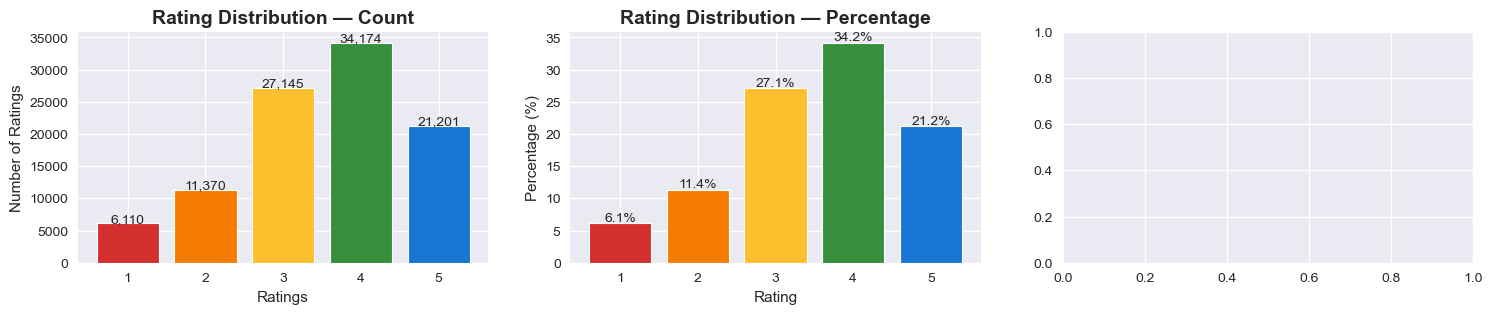

In [ ]:
# Rating Distribution Analysis
fig, axes = plt.subplots(1,3, figsize =(18,3))

# Chart 1 — Rating counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'],
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Rating Distribution — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ratings')
axes[0].set_ylabel('Number of Ratings')
for i, (val, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(val, count + 200, f'{count:,}', ha='center', fontsize=10)

# Chart 2 — Percentage distribution
rating_pct = rating_counts/ rating_counts.sum() * 100
axes[1].bar(rating_pct.index, rating_pct.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'],
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Rating Distribution — Percentage', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')

for i, (val,pct) in enumerate (zip(rating_pct.index, rating_pct.values)):
    axes[1].text(val, pct+0.3, f'{pct:.1f}%', ha='center', fontsize=10)

# Chart 3 — Cumulative distribution
